# 07 Feature-Based Neural Network

In this notebook, we train a neural network using the handcrafted features extracted from ECG, EDA, respiration, and temperature signals.

Unlike the raw-signal CNN and CNN-GRU models, this model uses statistical and signal-change features. The goal is to compare feature-based deep learning with classical machine learning.

In [1]:
# Basic libraries for file paths, arrays, tables, and plots
from pathlib import Path
import copy
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn is used for splitting, scaling, and evaluation
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# PyTorch is used to build and train the neural network
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Define main project folders
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

# Create result and model folders if needed
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Check whether the feature file exists
features_path = PROCESSED_DATA_DIR / "features.csv"

print("Features file:", features_path)
print("Features file exists:", features_path.exists())

Features file: ..\data\processed\features.csv
Features file exists: True


In [3]:
# Random seed helps make results more reproducible
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set CUDA seed if GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [4]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [5]:
# Load extracted feature dataset from Notebook 03
features_df = pd.read_csv(features_path)

# Show dataset shape and first rows
print("Feature dataset shape:", features_df.shape)

features_df.head()

Feature dataset shape: (2151, 75)


,subject_id,window_id,start_sec,end_sec,majority_ratio,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,...,Temp_rms,Temp_energy,Temp_mean_abs_change,Temp_std_change,Temp_max_abs_change,Temp_zero_crossings,Temp_skewness,Temp_kurtosis,label,label_name
0,S10,0,90.0,120.0,0.904762,0.001516,0.132416,-0.663895,0.785843,0.030716,...,33.897731,1149.056162,0.022942,0.032233,0.183929,0,-0.302280,3.753279,1,Neutral / Baseline
1,S10,1,105.0,135.0,1.000000,0.000542,0.136359,-0.574814,0.821457,0.031586,...,33.922503,1150.736193,0.024211,0.033127,0.177979,0,-0.395398,4.197550,1,Neutral / Baseline
2,S10,2,120.0,150.0,1.000000,0.001889,0.140376,-0.667923,0.821457,0.028976,...,33.949085,1152.540389,0.024425,0.033431,0.177979,0,-0.298644,3.715316,1,Neutral / Baseline
3,S10,3,135.0,165.0,1.000000,0.001967,0.154921,-0.667923,0.838211,0.019730,...,33.982891,1154.836868,0.024582,0.033548,0.179626,0,-0.029038,3.213001,1,Neutral / Baseline
4,S10,4,150.0,180.0,1.000000,0.000855,0.161409,-0.664948,0.838211,0.005791,...,34.028476,1157.937208,0.026112,0.035063,0.179871,0,-0.213312,2.793012,1,Neutral / Baseline


In [6]:
# Check how many samples belong to each class
class_distribution = features_df["label_name"].value_counts().reset_index()
class_distribution.columns = ["label_name", "window_count"]

class_distribution

,label_name,window_count
0,Neutral / Baseline,1154
1,Stress,644
2,Amusement,353


In [7]:
# Original label names
LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

# Neural networks need class labels starting from 0
LABEL_TO_INDEX = {
    1: 0,
    2: 1,
    3: 2
}

INDEX_TO_LABEL = {
    0: "Neutral / Baseline",
    1: "Stress",
    2: "Amusement"
}

# These columns are not input features
metadata_columns = [
    "subject_id",
    "window_id",
    "start_sec",
    "end_sec",
    "majority_ratio",
    "label",
    "label_name"
]

# Keep only numerical feature columns
feature_columns = [
    column for column in features_df.columns
    if column not in metadata_columns
]

print("Number of feature columns:", len(feature_columns))
print("First 10 feature columns:", feature_columns[:10])

Number of feature columns: 68
First 10 feature columns: ['ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max', 'ECG_median', 'ECG_range', 'ECG_q25', 'ECG_q75', 'ECG_iqr', 'ECG_rms']


In [8]:
# X contains input features
X = features_df[feature_columns].copy()

# y contains class labels converted from 1,2,3 to 0,1,2
y = features_df["label"].map(LABEL_TO_INDEX).values

# groups contain subject IDs for subject-independent splitting
groups = features_df["subject_id"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of subjects:", groups.nunique())
print("Labels:", np.unique(y))

X shape: (2151, 68)
y shape: (2151,)
Number of subjects: 15
Labels: [0 1 2]


In [9]:
# Check missing values before training
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Number of columns with missing values:", len(missing_values))

# Replace missing values with column means if any exist
if len(missing_values) > 0:
    X = X.fillna(X.mean())
    print("Missing values filled with column means.")
else:
    print("No missing values found.")

Number of columns with missing values: 0
No missing values found.


In [10]:
# First split: separate final test subjects
test_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_val_index, test_index = next(
    test_splitter.split(X, y, groups=groups)
)

X_train_val = X.iloc[train_val_index]
X_test = X.iloc[test_index]

y_train_val = y[train_val_index]
y_test = y[test_index]

groups_train_val = groups.iloc[train_val_index]
groups_test = groups.iloc[test_index]

# Second split: separate validation subjects from training subjects
val_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_index, val_index = next(
    val_splitter.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val.iloc[train_index]
X_val = X_train_val.iloc[val_index]

y_train = y_train_val[train_index]
y_val = y_train_val[val_index]

groups_train = groups_train_val.iloc[train_index]
groups_val = groups_train_val.iloc[val_index]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain subjects:", sorted(groups_train.unique()))
print("Validation subjects:", sorted(groups_val.unique()))
print("Test subjects:", sorted(groups_test.unique()))

Train shape: (1289, 68)
Validation shape: (429, 68)
Test shape: (433, 68)

Train subjects: ['S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S5', 'S9']
Validation subjects: ['S11', 'S7', 'S8']
Test subjects: ['S10', 'S4', 'S6']


In [11]:
# Make sure no subject appears in more than one split
train_subjects = set(groups_train.unique())
val_subjects = set(groups_val.unique())
test_subjects = set(groups_test.unique())

print("Train-validation overlap:", train_subjects.intersection(val_subjects))
print("Train-test overlap:", train_subjects.intersection(test_subjects))
print("Validation-test overlap:", val_subjects.intersection(test_subjects))

Train-validation overlap: set()
Train-test overlap: set()
Validation-test overlap: set()


In [12]:
# Count class samples in each split
train_counts = np.bincount(y_train, minlength=3)
val_counts = np.bincount(y_val, minlength=3)
test_counts = np.bincount(y_test, minlength=3)

split_distribution_df = pd.DataFrame({
    "class": [INDEX_TO_LABEL[i] for i in range(3)],
    "train_count": train_counts,
    "validation_count": val_counts,
    "test_count": test_counts
})

split_distribution_df

,class,train_count,validation_count,test_count
0,Neutral / Baseline,692,231,231
1,Stress,386,128,130
2,Amusement,211,70,72


In [13]:
# StandardScaler is fitted only on training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for PyTorch
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

print("Train scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Train scaled shape: (1289, 68)
Validation scaled shape: (429, 68)
Test scaled shape: (433, 68)


In [14]:
# Convert feature arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Convert labels to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor:", X_train_tensor.shape)
print("X_val_tensor:", X_val_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)

X_train_tensor: torch.Size([1289, 68])
X_val_tensor: torch.Size([429, 68])
X_test_tensor: torch.Size([433, 68])


In [15]:
# Batch size controls how many samples are processed at once
BATCH_SIZE = 32

# TensorDataset combines features and labels
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoaders create mini-batches
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 41
Validation batches: 14
Testing batches: 14


In [16]:
# Count class samples in training data
train_class_counts = np.bincount(y_train, minlength=3)

# Calculate balanced class weights
num_classes = 3
total_train_samples = len(y_train)

class_weights = total_train_samples / (num_classes * train_class_counts)

# Convert class weights to tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Training class counts:", train_class_counts)
print("Class weights:", class_weights)

Training class counts: [692 386 211]
Class weights: [0.62090559 1.11312608 2.03633491]


In [17]:
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        # Fully connected neural network for tabular features
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        # Forward pass through the MLP
        return self.network(x)

In [18]:
# Input dimension is the number of extracted features
input_dim = X_train_tensor.shape[1]
num_classes = 3

# Create model
model = FeatureMLP(
    input_dim=input_dim,
    num_classes=num_classes
).to(device)

# Weighted loss handles class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer trains the neural network
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Scheduler reduces learning rate when validation F1 stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

print(model)

FeatureMLP(
  (network): Sequential(
    (0): Linear(in_features=68, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [19]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # Put model in training mode
    model.train()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for batch_X, batch_y in data_loader:
        # Move data to CPU or GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Clear old gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and model update
        loss.backward()
        optimizer.step()
        
        # Store loss and predictions
        total_loss += loss.item() * batch_X.size(0)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate metrics
    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    
    return average_loss, accuracy, macro_f1

In [20]:
def evaluate_model(model, data_loader, criterion, device):
    # Put model in evaluation mode
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    # No gradients are needed during evaluation
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # Move data to CPU or GPU
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass only
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Store loss and predictions
            total_loss += loss.item() * batch_X.size(0)
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate metrics
    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    
    return average_loss, accuracy, macro_f1, np.array(all_targets), np.array(all_predictions)

In [21]:
# Maximum number of epochs
NUM_EPOCHS = 100

# Stop if validation F1 does not improve
PATIENCE = 15

# Store training history
history = []

best_val_f1 = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    # Train one epoch
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    # Validate after each epoch
    val_loss, val_acc, val_f1, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )
    
    # Update learning rate using validation F1
    scheduler.step(val_f1)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    
    # Save epoch result
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "learning_rate": current_lr
    })
    
    # Save best model using validation F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    print(
        f"Epoch {epoch + 1:03d}/{NUM_EPOCHS} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.6f}"
    )
    
    # Stop early if validation does not improve
    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation macro F1:", best_val_f1)

Epoch 001/100 | Train F1: 0.4827 | Val F1: 0.4983 | Val Loss: 0.9804 | LR: 0.001000
Epoch 002/100 | Train F1: 0.7334 | Val F1: 0.4355 | Val Loss: 1.0043 | LR: 0.001000
Epoch 003/100 | Train F1: 0.8075 | Val F1: 0.4017 | Val Loss: 1.2809 | LR: 0.001000
Epoch 004/100 | Train F1: 0.8538 | Val F1: 0.3731 | Val Loss: 1.5533 | LR: 0.001000
Epoch 005/100 | Train F1: 0.8715 | Val F1: 0.4811 | Val Loss: 1.6617 | LR: 0.001000
Epoch 006/100 | Train F1: 0.9019 | Val F1: 0.3260 | Val Loss: 2.0139 | LR: 0.001000
Epoch 007/100 | Train F1: 0.9051 | Val F1: 0.3339 | Val Loss: 2.1177 | LR: 0.000500
Epoch 008/100 | Train F1: 0.9163 | Val F1: 0.4283 | Val Loss: 2.2644 | LR: 0.000500
Epoch 009/100 | Train F1: 0.9331 | Val F1: 0.3847 | Val Loss: 2.1963 | LR: 0.000500
Epoch 010/100 | Train F1: 0.9206 | Val F1: 0.4473 | Val Loss: 2.0653 | LR: 0.000500
Epoch 011/100 | Train F1: 0.9444 | Val F1: 0.3823 | Val Loss: 2.3315 | LR: 0.000500
Epoch 012/100 | Train F1: 0.9228 | Val F1: 0.3192 | Val Loss: 2.7243 | LR: 0

In [22]:
# Convert training history to table
history_df = pd.DataFrame(history)

history_df.head()

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,learning_rate
0,1,0.969985,0.529092,0.482703,0.980390,0.526807,0.498252,0.001
1,2,0.690746,0.781226,0.733440,1.004342,0.463869,0.435534,0.001
2,3,0.458804,0.845617,0.807467,1.280869,0.428904,0.401707,0.001
3,4,0.336453,0.881303,0.853750,1.553273,0.382284,0.373146,0.001
4,5,0.274402,0.896819,0.871501,1.661674,0.463869,0.481105,0.001


In [23]:
# Save training history for GitHub documentation
history_path = RESULTS_DIR / "feature_mlp_training_history.csv"

history_df.to_csv(history_path, index=False)

print("Saved training history to:", history_path)

Saved training history to: ..\results\feature_mlp_training_history.csv


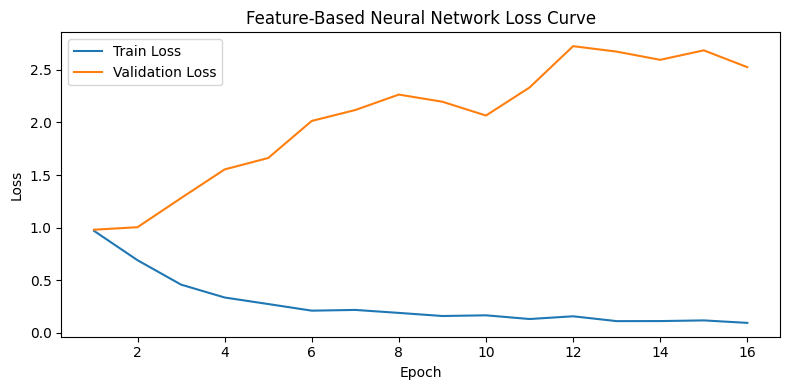

Saved figure to: ..\results\feature_mlp_loss_curve.png


In [24]:
# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Feature-Based Neural Network Loss Curve")
plt.legend()
plt.tight_layout()

output_path = RESULTS_DIR / "feature_mlp_loss_curve.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

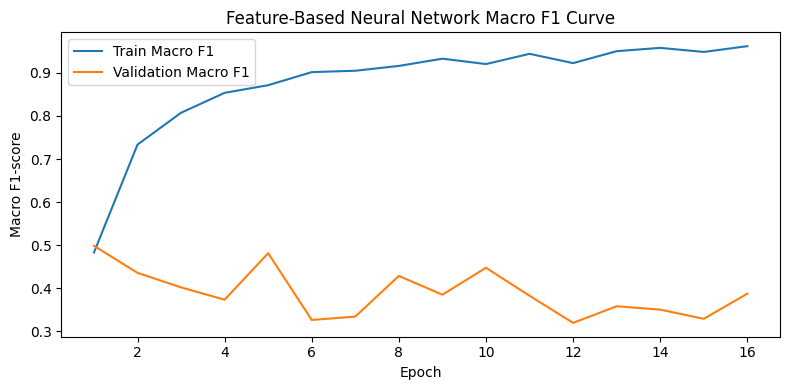

Saved figure to: ..\results\feature_mlp_macro_f1_curve.png


In [25]:
# Plot training and validation macro F1-score
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Feature-Based Neural Network Macro F1 Curve")
plt.legend()
plt.tight_layout()

output_path = RESULTS_DIR / "feature_mlp_macro_f1_curve.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [26]:
# Load best validation model before final testing
model.load_state_dict(best_model_state)

print("Loaded best model with validation macro F1:", best_val_f1)

Loaded best model with validation macro F1: 0.4982516466582905


In [27]:
# Evaluate the best model on unseen test subjects
test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

# Calculate extra metrics
test_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_acc, 4))
print("Final Test Macro Precision:", round(test_precision, 4))
print("Final Test Macro Recall:", round(test_recall, 4))
print("Final Test Macro F1:", round(test_f1, 4))

Final Test Loss: 0.9464
Final Test Accuracy: 0.4642
Final Test Macro Precision: 0.4636
Final Test Macro Recall: 0.409
Final Test Macro F1: 0.4274


In [28]:
# Create class names for readable report
class_names = [
    INDEX_TO_LABEL[0],
    INDEX_TO_LABEL[1],
    INDEX_TO_LABEL[2]
]

# Generate detailed classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                    precision    recall  f1-score   support

Neutral / Baseline       0.65      0.51      0.57       231
            Stress       0.66      0.55      0.60       130
         Amusement       0.08      0.17      0.11        72

          accuracy                           0.46       433
         macro avg       0.46      0.41      0.43       433
      weighted avg       0.56      0.46      0.50       433



In [29]:
# Save classification report as text file
report_path = RESULTS_DIR / "feature_mlp_classification_report.txt"

with open(report_path, "w") as file:
    file.write("Model: Feature-Based MLP\n\n")
    file.write(report)

print("Saved classification report to:", report_path)

Saved classification report to: ..\results\feature_mlp_classification_report.txt


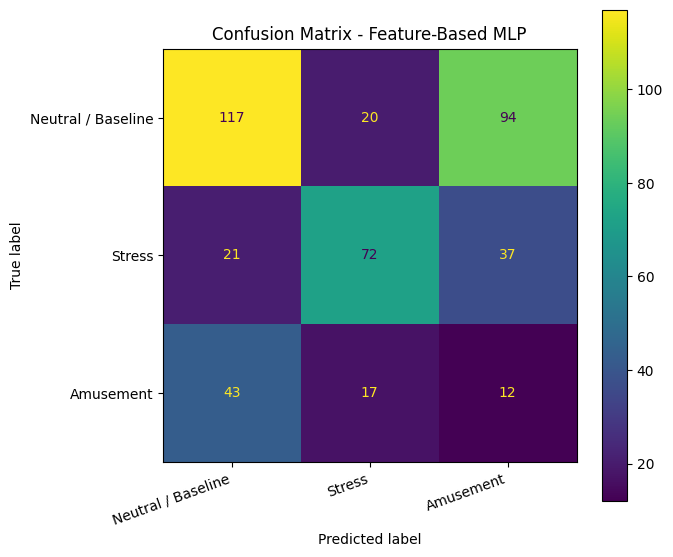

Saved confusion matrix to: ..\results\feature_mlp_confusion_matrix.png


In [30]:
# Confusion matrix shows class-wise prediction errors
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Feature-Based MLP")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "feature_mlp_confusion_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved confusion matrix to:", output_path)

In [31]:
# Save final result summary
feature_mlp_summary = pd.DataFrame([
    {
        "model": "Feature-Based MLP",
        "accuracy": test_acc,
        "macro_precision": test_precision,
        "macro_recall": test_recall,
        "macro_f1": test_f1,
        "best_validation_macro_f1": best_val_f1,
        "epochs_trained": len(history_df),
        "batch_size": BATCH_SIZE,
        "number_of_features": input_dim,
        "training_samples": X_train_tensor.shape[0],
        "validation_samples": X_val_tensor.shape[0],
        "testing_samples": X_test_tensor.shape[0],
        "training_subjects": ", ".join(sorted(groups_train.unique())),
        "validation_subjects": ", ".join(sorted(groups_val.unique())),
        "testing_subjects": ", ".join(sorted(groups_test.unique()))
    }
])

summary_path = RESULTS_DIR / "feature_mlp_summary.csv"

feature_mlp_summary.to_csv(summary_path, index=False)

feature_mlp_summary

,model,accuracy,macro_precision,macro_recall,macro_f1,best_validation_macro_f1,epochs_trained,batch_size,number_of_features,training_samples,validation_samples,testing_samples,training_subjects,validation_subjects,testing_subjects
0,Feature-Based MLP,0.464203,0.463625,0.409002,0.427367,0.498252,16,32,68,1289,429,433,"S13, S14, S15, S16, S17, S2, S3, S5, S9","S11, S7, S8","S10, S4, S6"


In [32]:
# Save model and scaler locally, not to GitHub
model_path = MODELS_DIR / "feature_mlp_model.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "scaler": scaler,
    "feature_columns": feature_columns,
    "label_mapping": INDEX_TO_LABEL,
    "model_name": "Feature-Based MLP"
}, model_path)

print("Saved model locally to:", model_path)

Saved model locally to: ..\models\feature_mlp_model.pt


In [33]:
# Load previous result files if available
ml_results_path = RESULTS_DIR / "ml_model_comparison.csv"
old_dl_summary_path = RESULTS_DIR / "dl_summary.csv"
improved_dl_summary_path = RESULTS_DIR / "improved_dl_summary.csv"

comparison_rows = []

# Add best classical ML result
if ml_results_path.exists():
    ml_results = pd.read_csv(ml_results_path)
    best_ml_row = ml_results.sort_values(by="macro_f1", ascending=False).iloc[0]
    
    comparison_rows.append({
        "model": best_ml_row["model"],
        "type": "Classical ML",
        "accuracy": best_ml_row["accuracy"],
        "macro_f1": best_ml_row["macro_f1"]
    })

# Add previous raw 1D CNN result
if old_dl_summary_path.exists():
    old_dl_summary = pd.read_csv(old_dl_summary_path)
    old_dl_row = old_dl_summary.iloc[0]
    
    comparison_rows.append({
        "model": old_dl_row["model"],
        "type": "Raw-Signal Deep Learning",
        "accuracy": old_dl_row["accuracy"],
        "macro_f1": old_dl_row["macro_f1"]
    })

# Add improved CNN-GRU result
if improved_dl_summary_path.exists():
    improved_dl_summary = pd.read_csv(improved_dl_summary_path)
    improved_dl_row = improved_dl_summary.iloc[0]
    
    comparison_rows.append({
        "model": improved_dl_row["model"],
        "type": "Raw-Signal Deep Learning",
        "accuracy": improved_dl_row["accuracy"],
        "macro_f1": improved_dl_row["macro_f1"]
    })

# Add feature-based MLP result
comparison_rows.append({
    "model": "Feature-Based MLP",
    "type": "Feature-Based Deep Learning",
    "accuracy": test_acc,
    "macro_f1": test_f1
})

all_model_comparison_df = pd.DataFrame(comparison_rows)

comparison_path = RESULTS_DIR / "all_model_comparison.csv"
all_model_comparison_df.to_csv(comparison_path, index=False)

all_model_comparison_df

,model,type,accuracy,macro_f1
0,Gradient Boosting,Classical ML,0.706697,0.577475
1,1D CNN,Raw-Signal Deep Learning,0.378753,0.358429
2,CNN-GRU,Raw-Signal Deep Learning,0.464203,0.380336
3,Feature-Based MLP,Feature-Based Deep Learning,0.464203,0.427367


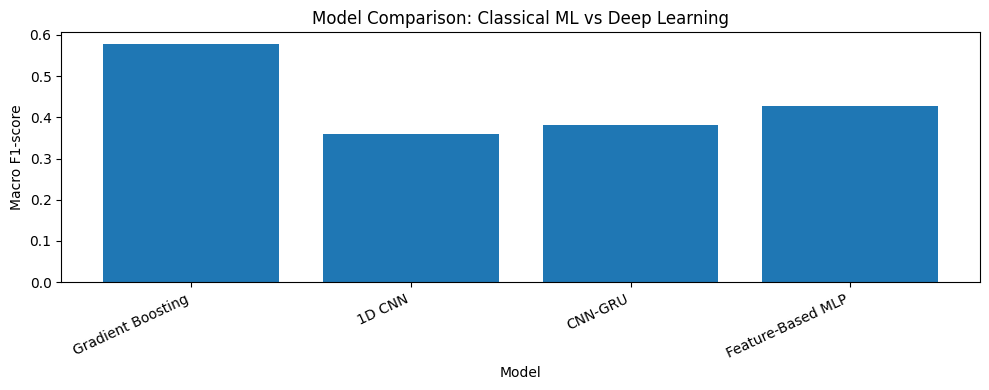

Saved figure to: ..\results\all_model_comparison_macro_f1.png


In [34]:
# Plot macro F1 comparison for all models
plt.figure(figsize=(10, 4))
plt.bar(all_model_comparison_df["model"], all_model_comparison_df["macro_f1"])
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison: Classical ML vs Deep Learning")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "all_model_comparison_macro_f1.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [35]:
# Select one test sample
sample_index = 0

sample_X = X_test_tensor[sample_index].unsqueeze(0).to(device)
sample_true_label = y_test_tensor[sample_index].item()

# Predict one sample
model.eval()

with torch.no_grad():
    output = model(sample_X)
    probabilities = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()

print("True label:", INDEX_TO_LABEL[sample_true_label])
print("Predicted label:", INDEX_TO_LABEL[predicted_label])
print("Class probabilities:")

for class_index, probability in enumerate(probabilities.cpu().numpy()[0]):
    print(INDEX_TO_LABEL[class_index], ":", round(float(probability), 4))

True label: Neutral / Baseline
Predicted label: Stress
Class probabilities:
Neutral / Baseline : 0.2805
Stress : 0.3664
Amusement : 0.3531
